# Linear real second-order reciprocity test

This notebook tests the first condition of Theorem 5.1 for real-valued second-order systems. The theorem says that a linear second-order system can compute its adjoint field on the same physical hardware when the dynamical operators are reciprocal:

$$
M^T=M,
\qquad
D^T=D,
\qquad
K(t)^T=K(t).
$$

The forward dynamics are

$$
M(p_M)\ddot u(t)+D(p_D)\dot u(t)+K(t;p_K)u(t)-f(t;p_f)=0,
\qquad
u(0)=u_0(p_0),
\qquad
\dot u(0)=v_0(p_0).
$$

We use a two-mode damped oscillator with explicit time dependence in the stiffness:

$$
M=
\begin{pmatrix}
m_0&0\\
0&m_1
\end{pmatrix},
\qquad
D=
\begin{pmatrix}
d_0&\gamma_g\\
-\gamma_g&d_1
\end{pmatrix},
$$

and

$$
K(t)=
\begin{pmatrix}
k_0+k_c+\alpha\cos(\Omega t)&-k_c+\beta\sin(\Omega t)+\rho\\
-k_c+\beta\sin(\Omega t)-\rho&k_1+k_c-\alpha\cos(\Omega t)
\end{pmatrix}.
$$

The parameters $\rho$ and $\gamma_g$ break reciprocity. When $\rho=0$ and $\gamma_g=0$, the system is reciprocal even though the damping $d_0,d_1$ is nonzero. This is the linear point of Theorem 5.1: damping is allowed in the physical adjoint if it is reciprocal.

The cost is

$$
\chi
=
\int_0^T \frac{q}{2}\|u(t)-r(t)\|^2\,dt
+
\frac{q_T}{2}\|u(T)-u_*\|^2
+
\frac{q_V}{2}\|\dot u(T)-v_*\|^2.
$$

Using reverse adjoint time $\tau=T-t$, the exact digital adjoint satisfies

$$
M^T\ddot a(\tau)
+D^T\dot a(\tau)
+K(T-\tau)^T a(\tau)
+\theta_u[u(T-\tau),T-\tau]=0,
$$

with initial conditions

$$
M^T a(0)=-\psi_{\dot u}[u(T),\dot u(T)],
\qquad
M^T\dot a(0)+D^T a(0)=-\psi_u[u(T),\dot u(T)].
$$

The physical adjoint run uses the same hardware operators instead:

$$
M\ddot a_{phys}(\tau)
+D\dot a_{phys}(\tau)
+K(T-\tau)a_{phys}(\tau)
+\theta_u[u(T-\tau),T-\tau]=0.
$$

Therefore $a_{phys}=a$ only in the reciprocal case. The gradient overlap is

$$
\frac{d\chi}{dp}
=
\int_0^T
 a(T-t)^T
\left[
M_p\ddot u(t)+D_p\dot u(t)+K_p(t)u(t)-f_p(t)
\right]dt,
$$

with boundary terms

$$
\frac{d\chi}{du_0}=-M^T\dot a(T)-D^T a(T),
\qquad
\frac{d\chi}{dv_0}=-M^T a(T).
$$

The Taylor tests below compare a reciprocal case, $\rho=\gamma_g=0$, with a nonreciprocal case, $\rho,\gamma_g\ne0$. The digital adjoint should pass in both cases. The physical adjoint should pass only in the reciprocal case.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, simpson

T = 6.0
Nt = 1001
rtol = 1e-10
atol = 1e-12

t_grid = np.linspace(0.0, T, Nt)

initial_condition_names = ["u0[0]", "u0[1]", "v0[0]", "v0[1]"]
mass_parameter_names = ["m0", "m1"]
damping_parameter_names = ["d0", "d1", "gyro"]
stiffness_parameter_names = ["k0", "k1", "kc", "rho", "alpha", "beta", "Omega"]
drive_parameter_names = ["A0", "A1", "omega_f"]
parameter_names = (
    initial_condition_names
    + mass_parameter_names
    + damping_parameter_names
    + stiffness_parameter_names
    + drive_parameter_names
)

q_traj = 0.5
q_T = 0.50
q_V = 0.5
u_target = np.array([0.10, -0.08])
v_target = np.array([0.02, 0.00])

np.set_printoptions(precision=6, suppress=False)


In [2]:
def make_parameters(rho, gyro):
    return np.array(
        [0.55, -0.20, 0.00, 0.18]
        + [1.00, 1.25]
        + [0.06, 0.09, gyro]
        + [1.40, 2.00, 0.45, rho, 0.18, 0.12, 1.10]
        + [0.10, -0.06, 0.80],
        dtype=float,
    )


def unpack(p):
    return dict(zip(parameter_names, p))


def initial_conditions(p):
    p = unpack(p)
    u0 = np.array([p["u0[0]"], p["u0[1]"]], dtype=float)
    v0 = np.array([p["v0[0]"], p["v0[1]"]], dtype=float)
    return u0, v0


def M(p):
    p = unpack(p)
    return np.array([[p["m0"], 0.0], [0.0, p["m1"]]], dtype=float)


def D(p):
    p = unpack(p)
    return np.array([[p["d0"], p["gyro"]], [-p["gyro"], p["d1"]]], dtype=float)


def K(t, p):
    p = unpack(p)
    ct = np.cos(p["Omega"] * t)
    st = np.sin(p["Omega"] * t)
    return np.array(
        [
            [p["k0"] + p["kc"] + p["alpha"] * ct, -p["kc"] + p["beta"] * st + p["rho"]],
            [-p["kc"] + p["beta"] * st - p["rho"], p["k1"] + p["kc"] - p["alpha"] * ct],
        ],
        dtype=float,
    )


def drive(t, p):
    p = unpack(p)
    return np.array([p["A0"] * np.sin(p["omega_f"] * t), p["A1"] * np.cos(p["omega_f"] * t)], dtype=float)


def dM_dp(name):
    if name == "m0":
        return np.array([[1.0, 0.0], [0.0, 0.0]])
    if name == "m1":
        return np.array([[0.0, 0.0], [0.0, 1.0]])
    raise KeyError(name)


def dD_dp(name):
    if name == "d0":
        return np.array([[1.0, 0.0], [0.0, 0.0]])
    if name == "d1":
        return np.array([[0.0, 0.0], [0.0, 1.0]])
    if name == "gyro":
        return np.array([[0.0, 1.0], [-1.0, 0.0]])
    raise KeyError(name)


def dK_dp(t, p, name):
    p_dict = unpack(p)
    ct = np.cos(p_dict["Omega"] * t)
    st = np.sin(p_dict["Omega"] * t)
    if name == "k0":
        return np.array([[1.0, 0.0], [0.0, 0.0]])
    if name == "k1":
        return np.array([[0.0, 0.0], [0.0, 1.0]])
    if name == "kc":
        return np.array([[1.0, -1.0], [-1.0, 1.0]])
    if name == "rho":
        return np.array([[0.0, 1.0], [-1.0, 0.0]])
    if name == "alpha":
        return np.array([[ct, 0.0], [0.0, -ct]])
    if name == "beta":
        return np.array([[0.0, st], [st, 0.0]])
    if name == "Omega":
        dct = -t * np.sin(p_dict["Omega"] * t)
        dst = t * np.cos(p_dict["Omega"] * t)
        return np.array(
            [
                [p_dict["alpha"] * dct, p_dict["beta"] * dst],
                [p_dict["beta"] * dst, -p_dict["alpha"] * dct],
            ]
        )
    raise KeyError(name)


def drive_dp(t, p, name):
    p_dict = unpack(p)
    wt = p_dict["omega_f"] * t
    if name == "A0":
        return np.array([np.sin(wt), 0.0])
    if name == "A1":
        return np.array([0.0, np.cos(wt)])
    if name == "omega_f":
        return np.array([p_dict["A0"] * t * np.cos(wt), -p_dict["A1"] * t * np.sin(wt)])
    raise KeyError(name)


In [3]:
def u_reference(t):
    return np.array([0.08 * np.sin(0.45 * t), -0.05 * np.cos(0.70 * t)], dtype=float)


def theta_value(u, t):
    r = u_reference(t)
    return 0.5 * q_traj * np.sum((u - r) ** 2)


def theta_u(u, t):
    return q_traj * (u - u_reference(t))


def psi_value(u, v):
    return 0.5 * q_T * np.sum((u - u_target) ** 2) + 0.5 * q_V * np.sum((v - v_target) ** 2)


def psi_u(u, v):
    return q_T * (u - u_target)


def psi_v(u, v):
    return q_V * (v - v_target)


def acceleration(t, u, v, p):
    return np.linalg.solve(M(p), drive(t, p) - D(p) @ v - K(t, p) @ u)


def forward_rhs(t, z, p):
    u = z[:2]
    v = z[2:]
    return np.r_[v, acceleration(t, u, v, p)]


def solve_forward(p):
    u0, v0 = initial_conditions(p)
    sol = solve_ivp(
        lambda t, z: forward_rhs(t, z, p),
        (0.0, T),
        np.r_[u0, v0],
        t_eval=t_grid,
        dense_output=True,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def objective(p):
    sol = solve_forward(p)
    values = [theta_value(sol.y[:2, k], sol.t[k]) for k in range(sol.t.size)]
    return simpson(values, x=sol.t) + psi_value(sol.y[:2, -1], sol.y[2:, -1])


In [4]:
def solve_digital_adjoint(p, forward):
    M_mat = M(p)
    D_mat = D(p)
    uT = forward.y[:2, -1]
    vT = forward.y[2:, -1]

    a0 = np.linalg.solve(M_mat.T, -psi_v(uT, vT))
    adot0 = np.linalg.solve(M_mat.T, -D_mat.T @ a0 - psi_u(uT, vT))

    def rhs(tau, z):
        t_forward = T - tau
        u = forward.sol(t_forward)[:2]
        a = z[:2]
        adot = z[2:]
        addot = np.linalg.solve(
            M_mat.T,
            -D_mat.T @ adot - K(t_forward, p).T @ a - theta_u(u, t_forward),
        )
        return np.r_[adot, addot]

    sol = solve_ivp(
        rhs,
        (0.0, T),
        np.r_[a0, adot0],
        t_eval=t_grid,
        dense_output=True,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def solve_physical_adjoint(p, forward):
    M_mat = M(p)
    D_mat = D(p)
    uT = forward.y[:2, -1]
    vT = forward.y[2:, -1]

    a0 = np.linalg.solve(M_mat, -psi_v(uT, vT))
    adot0 = np.linalg.solve(M_mat, -D_mat @ a0 - psi_u(uT, vT))

    def rhs(tau, z):
        t_forward = T - tau
        u = forward.sol(t_forward)[:2]
        a = z[:2]
        adot = z[2:]
        addot = np.linalg.solve(
            M_mat,
            -D_mat @ adot - K(t_forward, p) @ a - theta_u(u, t_forward),
        )
        return np.r_[adot, addot]

    sol = solve_ivp(
        rhs,
        (0.0, T),
        np.r_[a0, adot0],
        t_eval=t_grid,
        dense_output=True,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def gradient_from_adjoint(p, forward, adjoint):
    M_mat = M(p)
    D_mat = D(p)
    aT = adjoint.sol(T)[:2]
    adotT = adjoint.sol(T)[2:]

    grad_u0 = -M_mat.T @ adotT - D_mat.T @ aT
    grad_v0 = -M_mat.T @ aT
    gradient = list(grad_u0) + list(grad_v0)

    for name in mass_parameter_names:
        dM = dM_dp(name)
        values = []
        for t in t_grid:
            u = forward.sol(t)[:2]
            v = forward.sol(t)[2:]
            uddot = acceleration(t, u, v, p)
            a = adjoint.sol(T - t)[:2]
            values.append(a @ (dM @ uddot))
        gradient.append(simpson(values, x=t_grid))

    for name in damping_parameter_names:
        dD = dD_dp(name)
        values = []
        for t in t_grid:
            v = forward.sol(t)[2:]
            a = adjoint.sol(T - t)[:2]
            values.append(a @ (dD @ v))
        gradient.append(simpson(values, x=t_grid))

    for name in stiffness_parameter_names:
        values = []
        for t in t_grid:
            u = forward.sol(t)[:2]
            a = adjoint.sol(T - t)[:2]
            values.append(a @ (dK_dp(t, p, name) @ u))
        gradient.append(simpson(values, x=t_grid))

    for name in drive_parameter_names:
        values = []
        for t in t_grid:
            a = adjoint.sol(T - t)[:2]
            values.append(a @ (-drive_dp(t, p, name)))
        gradient.append(simpson(values, x=t_grid))

    return np.array(gradient, dtype=float)


def taylor_errors(p, gradients, h_values, direction):
    chi0 = objective(p)
    p_scale = np.mean(np.abs(p))
    errors = {}
    for label, gradient in gradients.items():
        errors[label] = np.array([
            abs(objective(p + h * p_scale * direction) - chi0 - gradient @ (h * p_scale * direction))
            for h in h_values
        ])
    return errors


def reciprocity_defects(p):
    M_defect = np.linalg.norm(M(p) - M(p).T)
    D_defect = np.linalg.norm(D(p) - D(p).T)
    K_defect = max(np.linalg.norm(K(t, p) - K(t, p).T) for t in t_grid[::25])
    return M_defect, D_defect, K_defect


def adjoint_field_error(digital, physical):
    numerator = simpson(np.sum((digital.y[:2] - physical.y[:2]) ** 2, axis=0), x=t_grid)
    denominator = simpson(np.sum(digital.y[:2] ** 2, axis=0), x=t_grid)
    return np.sqrt(numerator / denominator)


In [5]:
def solve_case(label, rho, gyro):
    p = make_parameters(rho=rho, gyro=gyro)
    forward = solve_forward(p)
    digital = solve_digital_adjoint(p, forward)
    physical = solve_physical_adjoint(p, forward)
    grad_digital = gradient_from_adjoint(p, forward, digital)
    grad_physical = gradient_from_adjoint(p, forward, physical)
    return {
        "label": label,
        "p": p,
        "forward": forward,
        "digital": digital,
        "physical": physical,
        "grad_digital": grad_digital,
        "grad_physical": grad_physical,
    }


cases = [
    solve_case("reciprocal", rho=0.0, gyro=0.0),
    solve_case("nonreciprocal", rho=0.30, gyro=0.18),
]

for result in cases:
    p = result["p"]
    M_defect, D_defect, K_defect = reciprocity_defects(p)
    rel_field_error = adjoint_field_error(result["digital"], result["physical"])
    rel_grad_error = np.linalg.norm(result["grad_physical"] - result["grad_digital"]) / np.linalg.norm(result["grad_digital"])
    print(f"{result['label']} case")
    print(f"  rho={unpack(p)['rho']:.2f}, gyro={unpack(p)['gyro']:.2f}")
    print(f"  ||M-M.T||: {M_defect:.3e}")
    print(f"  ||D-D.T||: {D_defect:.3e}")
    print(f"  max_t ||K(t)-K(t).T||: {K_defect:.3e}")
    print(f"  relative physical/digital field error: {rel_field_error:.3e}")
    print(f"  relative physical/digital gradient error: {rel_grad_error:.3e}")
    print()


reciprocal case
  rho=0.00, gyro=0.00
  ||M-M.T||: 0.000e+00
  ||D-D.T||: 0.000e+00
  max_t ||K(t)-K(t).T||: 0.000e+00
  relative physical/digital field error: 0.000e+00
  relative physical/digital gradient error: 0.000e+00

nonreciprocal case
  rho=0.30, gyro=0.18
  ||M-M.T||: 0.000e+00
  ||D-D.T||: 5.091e-01
  max_t ||K(t)-K(t).T||: 8.485e-01
  relative physical/digital field error: 6.208e-01
  relative physical/digital gradient error: 7.233e-01



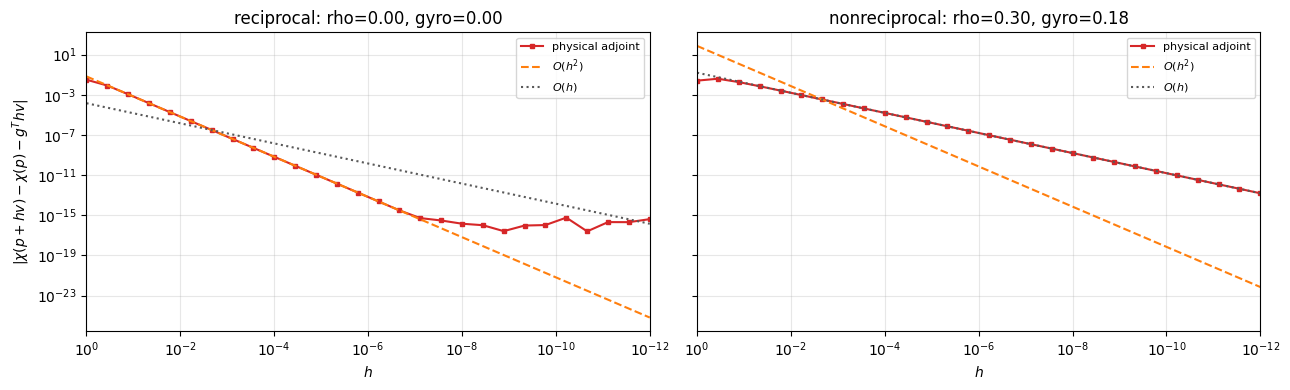

In [6]:
rng = np.random.default_rng(4)
direction = rng.normal(size=len(parameter_names))
direction = direction / np.linalg.norm(direction)
h_values = np.logspace(0, -12, 28)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, result in zip(axes, cases):
    errors = taylor_errors(
        result["p"],
        {"physical adjoint": result["grad_physical"]},
        h_values,
        direction,
    )
    anchor = 6
    ref2 = errors["physical adjoint"][anchor] * (h_values / h_values[anchor]) ** 2
    ref1 = errors["physical adjoint"][anchor] * (h_values / h_values[anchor])

    ax.loglog(h_values, errors["physical adjoint"], "s-", ms=3, color="tab:red", label="physical adjoint")
    ax.loglog(h_values, ref2, "--", color="tab:orange", label=r"$O(h^2)$")
    ax.loglog(h_values, ref1, ":", color="0.35", label=r"$O(h)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"$h$")
    ax.set_title(
        f"{result['label']}: rho={unpack(result['p'])['rho']:.2f}, "
        f"gyro={unpack(result['p'])['gyro']:.2f}"
    )
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$|\chi(p+h v)-\chi(p)-g^T h v|$")
plt.tight_layout()
plt.show()


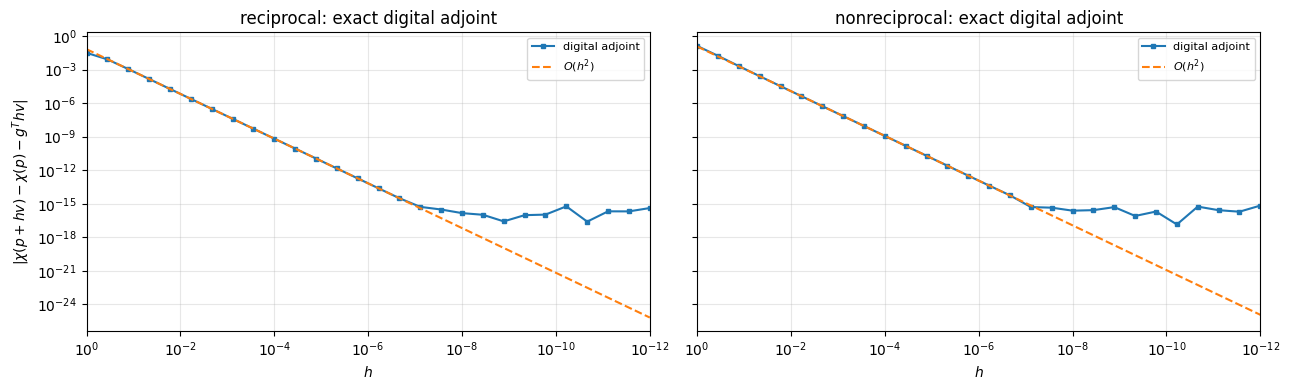

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, result in zip(axes, cases):
    errors = taylor_errors(
        result["p"],
        {"digital adjoint": result["grad_digital"]},
        h_values,
        direction,
    )
    anchor = 6
    ref2 = errors["digital adjoint"][anchor] * (h_values / h_values[anchor]) ** 2

    ax.loglog(h_values, errors["digital adjoint"], "s-", ms=3, color="tab:blue", label="digital adjoint")
    ax.loglog(h_values, ref2, "--", color="tab:orange", label=r"$O(h^2)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"$h$")
    ax.set_title(f"{result['label']}: exact digital adjoint")
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$|\chi(p+h v)-\chi(p)-g^T h v|$")
plt.tight_layout()
plt.show()
